<a href="https://colab.research.google.com/github/Abhishek24288/Deep-Learning/blob/main/DL_case3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
!unzip dataset.zip

Archive:  dataset.zip
replace dataset/no/1 no.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
IMG_SIZE = 224

def load_data(path):
    images, labels = [], []

    for label in ['yes', 'no']:
        folder = os.path.join(path, label)

        for file in os.listdir(folder):
            img_path = os.path.join(folder, file)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            images.append(img)
            labels.append(1 if label == 'yes' else 0)

    return np.array(images), np.array(labels)


X, y = load_data("dataset")

print("Data shape:", X.shape, y.shape)

Data shape: (253, 224, 224, 3) (253,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(224,224,3))

x = Conv2D(32, (3,3), activation='relu')(inputs)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D(2,2)(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.6287 - loss: 1.5058 - val_accuracy: 0.7843 - val_loss: 0.5969
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8317 - loss: 0.4520 - val_accuracy: 0.8627 - val_loss: 0.4676
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8713 - loss: 0.3656 - val_accuracy: 0.8627 - val_loss: 0.3910
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8812 - loss: 0.2778 - val_accuracy: 0.8431 - val_loss: 0.5071
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9604 - loss: 0.1623 - val_accuracy: 0.8235 - val_loss: 0.4400
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9752 - loss: 0.1120 - val_accuracy: 0.8431 - val_loss: 0.4759
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9752 - loss: 0.0606 - val_accuracy: 0.8627 - val_loss: 0.6327
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9851 - loss: 0.0413 - val_accuracy: 0.8627 - val_loss: 0.4416

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8235 - loss: 0.4531
Test Accuracy: 0.8235294222831726


In [ ]:
def get_gradcam(model, img):
    img = np.expand_dims(img, axis=0)

    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / np.max(heatmap) if np.max(heatmap) != 0 else heatmap

    heatmap = cv2.resize(heatmap, (224,224))

    return heatmap

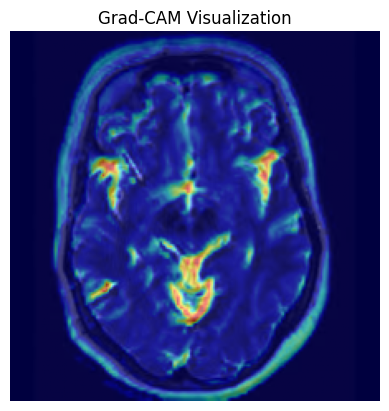

In [ ]:
img = X_test[0]

heatmap = get_gradcam(model, img)

plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Grad-CAM Visualization")
plt.axis('off')
plt.show()